https://medium.com/@lokaregns/fine-tuning-transformers-with-custom-dataset-classification-task-f261579ae068


## 1. Libraries and dataset Load

In [ ]:
%pip install transformers


In [13]:
import pandas as pd
import numpy as np
import seaborn as sns

import torch

from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split


In [14]:
df = pd.read_csv('comments_sentiments.csv',encoding="utf-8")


In [15]:
len(df)

3994

In [16]:
df = df.sample(frac=1).reset_index(drop=True)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3994 entries, 0 to 3993
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Comments    3994 non-null   object
 1   Sentiments  3994 non-null   object
dtypes: object(2)
memory usage: 62.5+ KB


In [18]:
df = df[['Comments','Sentiments']]

In [20]:
df['Sentiments'] = df['Sentiments'].str.lower()

<Axes: >

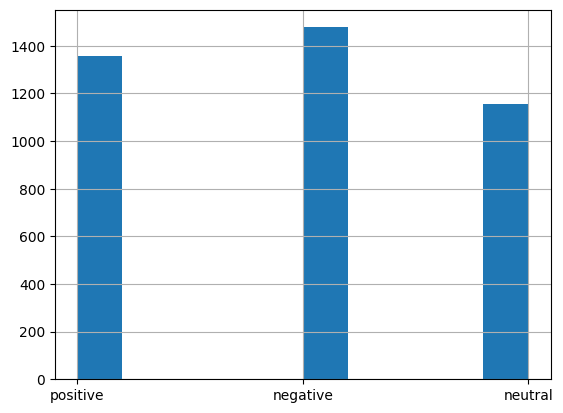

In [21]:
df['Sentiments'].hist()

## 2. LABEL ENCODING

In [ ]:
target_map = { 'positive': 1, 'negative': 0, 'neutral': 2,"sarcasm":3} #text->number
df['target'] = df['Sentiments'].map(target_map)

In [24]:
df["target"].value_counts()

target
0    1478
1    1359
2    1157
Name: count, dtype: int64

In [ ]:
df1 = df[['Comments','target']]
df1.columns = ['sentence','label']
df1.to_csv('data.csv', index = False) #data.csv file is created


## HuggingFace Dataset & Train/Test Split

In [26]:
!pip install datasets

  Using cached pyarrow-18.0.0-cp311-cp311-win_amd64.whl.metadata (3.4 kB)
  Using cached dill-0.3.8-py3-none-any.whl.metadata (10 kB)
  Using cached xxhash-3.5.0-cp311-cp311-win_amd64.whl.metadata (13 kB)
  Using cached multiprocess-0.70.16-py311-none-any.whl.metadata (7.2 kB)
  Using cached fsspec-2024.9.0-py3-none-any.whl.metadata (11 kB)
  Using cached aiohappyeyeballs-2.4.3-py3-none-any.whl.metadata (6.1 kB)
  Using cached aiosignal-1.3.1-py3-none-any.whl.metadata (4.0 kB)
  Using cached attrs-24.2.0-py3-none-any.whl.metadata (11 kB)
  Using cached frozenlist-1.5.0-cp311-cp311-win_amd64.whl.metadata (14 kB)
  Using cached multidict-6.1.0-cp311-cp311-win_amd64.whl.metadata (5.1 kB)
  Using cached propcache-0.2.0-cp311-cp311-win_amd64.whl.metadata (7.9 kB)
Using cached dill-0.3.8-py3-none-any.whl (116 kB)
Using cached fsspec-2024.9.0-py3-none-any.whl (179 kB)
Using cached multiprocess-0.70.16-py311-none-any.whl (143 kB)
Using cached pyarrow-18.0.0-cp311-cp311-win_amd64.whl (25.1 MB)


In [27]:
from datasets import load_dataset
raw_dataset = load_dataset("csv", data_files = "data.csv")

Generating train split: 3994 examples [00:00, 131417.49 examples/s]


In [28]:
raw_dataset

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 3994
    })
})

In [29]:
split = raw_dataset['train'].train_test_split(test_size=0.2, seed=42)

## 4: Tokenization (BERT Input Preparation)

In [30]:
from transformers import AutoTokenizer
checkpoint = 'bert-base-cased'
tokernizer = AutoTokenizer.from_pretrained(checkpoint)


d:\intent classication\.venv\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ragut\.cache\huggingface\hub\models--bert-base-cased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [31]:
def tokenize_fn(batch):
  return tokernizer(batch['sentence'], truncation = True)


In [32]:
tokenized_dataset = split.map(tokenize_fn, batched = True)

Map:   0%|          | 0/3195 [00:00<?, ? examples/s]

Map: 100%|██████████| 799/799 [00:00<00:00, 8585.04 examples/s]


## 5: Model Creation

In [33]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments


In [34]:
import torch

In [35]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [36]:

model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels = 4)
model = model.to(device)


Error while downloading from https://cdn-lfs.hf.co/bert-base-cased/1d8bdcee6021e2c25f0325e84889b61c2eb26b843eef5659c247af138d64f050?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27model.safetensors%3B+filename%3D%22model.safetensors%22%3B&Expires=1732627021&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTczMjYyNzAyMX19LCJSZXNvdXJjZSI6Imh0dHBzOi8vY2RuLWxmcy5oZi5jby9iZXJ0LWJhc2UtY2FzZWQvMWQ4YmRjZWU2MDIxZTJjMjVmMDMyNWU4NDg4OWI2MWMyZWIyNmI4NDNlZWY1NjU5YzI0N2FmMTM4ZDY0ZjA1MD9yZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW9uPSoifV19&Signature=jOOOJ873XDvQtCPMiPg4dzEloBvyWd1V%7Ec2zGgU%7EWDlY1ZZ2GzeJV7d8V75LcYwpqXqMffAtkofGDmmu%7EmcsIwIKveqr-E6fg%7ETTtaHYZxo3cNOh6GZlIl0Ht6lbsWH%7EaLpX5QZkYQkHi9LN5IUIWjzRlbutG5lA1GOgzQIcQ4EtDLdIJnZbNVrx2wquzKPtGq3O3D-uquRFyUlFU0BoTA0qiYdqQJAP7DuEdi9VW1UCwy9m8wqAVV91zvQ6xYiamyDRKpoLTEul0DwNxVAmlgo9ILr8S1qBcgNz6BuX03uZggfurW5VUZljM5JEJeuBOkBU6e-bbJZxDNfZEQQOrA__&Key-Pair-Id=K3RPWS32NSSJCE: HTTPSConnectionPool(host='cdn-l

ReadTimeout: (ReadTimeoutError("HTTPSConnectionPool(host='cdn-lfs.hf.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 215639c6-d8a5-4cbf-aa8f-add9af30335e)')

In [ ]:
!pip install torchinfo

In [ ]:
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                                       Param #
BertForSequenceClassification                                --
├─BertModel: 1-1                                             --
│    └─BertEmbeddings: 2-1                                   --
│    │    └─Embedding: 3-1                                   22,268,928
│    │    └─Embedding: 3-2                                   393,216
│    │    └─Embedding: 3-3                                   1,536
│    │    └─LayerNorm: 3-4                                   1,536
│    │    └─Dropout: 3-5                                     --
│    └─BertEncoder: 2-2                                      --
│    │    └─ModuleList: 3-6                                  85,054,464
│    └─BertPooler: 2-3                                       --
│    │    └─Linear: 3-7                                      590,592
│    │    └─Tanh: 3-8                                        --
├─Dropout: 1-2                                               --
├─L

## 6: Training Configuration

In [ ]:
training_args = TrainingArguments(output_dir='training_dir',
                                  evaluation_strategy='epoch',
                                  save_strategy='epoch',
                                  num_train_epochs=10,
                                  per_device_train_batch_size=16,
                                  per_device_eval_batch_size=64,
                                  )


/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


## 7: Metrics Calculation

In [ ]:
def compute_metrics(logits_and_labels):
  logits, labels = logits_and_labels
  predictions = np.argmax(logits, axis=-1)
  acc = np.mean(predictions == labels)
  f1 = f1_score(labels, predictions, average = 'micro')
  return {'accuracy': acc, 'f1_score': f1}


## 8: Trainer & Training

In [ ]:
trainer = Trainer(model,
                  training_args,
                  train_dataset = tokenized_dataset["train"],
                  eval_dataset = tokenized_dataset["test"],
                  tokenizer=tokernizer,
                  compute_metrics=compute_metrics)


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Score
1,0.144300,0.174008,0.928546,0.928546
2,0.114800,0.131774,0.940336,0.940336
3,0.102800,0.125623,0.939979,0.939979
4,0.090400,0.150943,0.938549,0.938549


Epoch,Training Loss,Validation Loss,Accuracy,F1 Score
1,0.144300,0.174008,0.928546,0.928546
2,0.114800,0.131774,0.940336,0.940336
3,0.102800,0.125623,0.939979,0.939979
4,0.090400,0.150943,0.938549,0.938549
5,0.069100,0.213272,0.938192,0.938192
6,0.061300,0.234479,0.935334,0.935334
7,0.054000,0.264066,0.937835,0.937835
8,0.050700,0.284115,0.936406,0.936406
9,0.048700,0.292277,0.938549,0.938549
10,0.048300,0.299061,0.938192,0.938192


TrainOutput(global_step=7000, training_loss=0.0775513082231794, metrics={'train_runtime': 749.7809, 'train_samples_per_second': 149.31, 'train_steps_per_second': 9.336, 'total_flos': 993104817071952.0, 'train_loss': 0.0775513082231794, 'epoch': 10.0})

## 9: Saving & Inference

In [ ]:
! ls training_dir #Trained model files

checkpoint-1400  checkpoint-2800  checkpoint-4200  checkpoint-5600  checkpoint-700   runs
checkpoint-2100  checkpoint-3500  checkpoint-4900  checkpoint-6300  checkpoint-7000


In [1]:
from transformers import pipeline

d:\intent classication\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from transformers import AutoModel, AutoTokenizer

model = AutoModel.from_pretrained("intent classification")
tokenizer = AutoTokenizer.from_pretrained("intent classification")


In [5]:
saved_model = pipeline('text-classification',
                       model = 'intent classification')


In [ ]:
predictions = saved_model(split['test']['sentence'])


In [ ]:
predictions[:10]


[{'label': 'LABEL_0', 'score': 0.5158452391624451},
 {'label': 'LABEL_0', 'score': 0.999913215637207},
 {'label': 'LABEL_2', 'score': 0.9993313550949097},
 {'label': 'LABEL_0', 'score': 0.9999125003814697},
 {'label': 'LABEL_3', 'score': 0.9999499320983887},
 {'label': 'LABEL_3', 'score': 0.9999401569366455},
 {'label': 'LABEL_0', 'score': 0.9999125003814697},
 {'label': 'LABEL_2', 'score': 0.9999810457229614},
 {'label': 'LABEL_2', 'score': 0.9998214840888977},
 {'label': 'LABEL_2', 'score': 0.9999815225601196}]

In [8]:
saved_model(["This video was amazing! Really well put together and super helpful—thank you for sharing this!","good video"])

[{'label': 'LABEL_1', 'score': 0.9999649524688721},
 {'label': 'LABEL_1', 'score': 0.9999477863311768}]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
# Copy your folder to Drive
!cp -r /content/training_dir "/content/drive/MyDrive/sentiment/training_1"

In [ ]:
def get_label(d):
  return int(d['label'].split('_')[1])
predictions = [get_label(d) for d in predictions]


NameError: name 'predictions' is not defined

## Final Accuracy

In [ ]:
print("acc:",accuracy_score(split['test']['label'], predictions))


acc: 0.9506666666666667


In [ ]:
print("f1:",f1_score(split['test']['label'], predictions, average = 'macro'))


f1: 0.9489530752014825


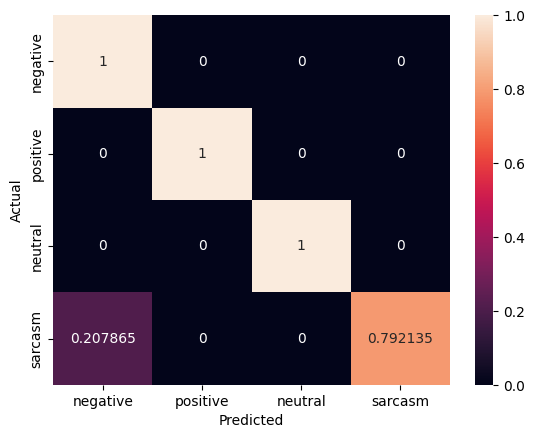

In [ ]:
def plot_cm(cm):
  classes = ['negative','positive','neutral','sarcasm']
  df_cm = pd.DataFrame(cm, index=classes, columns=classes)
  ax = sns.heatmap(df_cm, annot = True, fmt='g')
  ax.set_xlabel('Predicted')
  ax.set_ylabel('Actual')

cm = confusion_matrix(split['test']['label'],predictions, normalize = 'true')
plot_cm(cm)


In [ ]:
import pandas as pd

# Data for the DataFrame
data = {
    'comment': [
        "This video is exactly what I needed! Thanks for making it so clear and helpful.",
        "Absolutely amazing content! Keep up the fantastic work!",
        "I’ve learned so much from this – can’t wait for the next one!",
        "The production quality here is outstanding; very professional!",
        "You’re a natural at explaining things. Subscribed immediately!",
        "This was a game-changer for me. Thank you so much!",
        "Incredible video! You’ve got a new fan right here.",
        "I didn’t expect to enjoy this so much. Awesome work!",
        "This video deserves way more views. Top-notch content!",
        "Finally, someone who explains it clearly – love it!",
        "This video was such a waste of time. I didn’t learn anything.",
        "The sound quality here is horrible. Couldn’t hear a thing!",
        "This could have been explained so much better. Disappointed.",
        "I’m sorry, but this wasn’t helpful at all.",
        "There’s too much rambling. Get to the point!",
        "This video didn’t live up to the title at all.",
        "Not what I expected. Wouldn’t recommend.",
        "The editing was all over the place; very distracting.",
        "I’ve seen better explanations elsewhere, unfortunately.",
        "It feels like you’re just stretching this video for more watch time.",
        "Thanks for sharing this video. It’s got some useful info.",
        "Interesting points, but I think I need to watch it again.",
        "I didn’t know that before; something to think about.",
        "Decent video, though I might need to look into it more.",
        "The content is okay. Not bad, not amazing.",
        "I watched it, but I’m not sure how I feel about it yet.",
        "Appreciate the effort you put in here. Not bad.",
        "Useful info, though I think there’s more to cover.",
        "A bit long for my taste, but informative.",
        "This was alright. Just what I was looking for, I guess.",
        "Oh wow, such groundbreaking content… never seen anything like it (yawn).",
        "Just what I needed – another 20-minute video that says nothing. Bravo!",
        "Ah yes, I’m sure you’re the first person to ever think of this.",
        "Thanks for the crystal-clear explanation. Couldn’t possibly be more confusing!",
        "Wow, I didn’t know something so simple could take 15 minutes to explain.",
        "Oh, you really got to the point… after about 10 minutes!",
        "Amazing, I now know less than when I started watching.",
        "Such riveting content. I was totally awake the whole time!",
        "Just subscribed… so I can remember not to watch again.",
        "I feel so enlightened after this. Might even change my life… not really."
    ],
    'sentiment': [
        'Positive', 'Positive', 'Positive', 'Positive', 'Positive',
        'Positive', 'Positive', 'Positive', 'Positive', 'Positive',
        'Negative', 'Negative', 'Negative', 'Negative', 'Negative',
        'Negative', 'Negative', 'Negative', 'Negative', 'Negative',
        'Negative', 'Neutral', 'Neutral', 'Neutral', 'Neutral',
        'Neutral', 'Neutral', 'Neutral', 'Neutral', 'Neutral',
        'Neutral', 'Sarcasm', 'Sarcasm', 'Sarcasm', 'Sarcasm',
        'Sarcasm', 'Sarcasm', 'Sarcasm', 'Sarcasm', 'Sarcasm'
    ]
}

# Create the DataFrame
comments_df = pd.DataFrame(data)

# Display the DataFrame
print(comments_df)


                                              comment sentiment
0   This video is exactly what I needed! Thanks fo...  Positive
1   Absolutely amazing content! Keep up the fantas...  Positive
2   I’ve learned so much from this – can’t wait fo...  Positive
3   The production quality here is outstanding; ve...  Positive
4   You’re a natural at explaining things. Subscri...  Positive
5   This was a game-changer for me. Thank you so m...  Positive
6   Incredible video! You’ve got a new fan right h...  Positive
7   I didn’t expect to enjoy this so much. Awesome...  Positive
8   This video deserves way more views. Top-notch ...  Positive
9   Finally, someone who explains it clearly – lov...  Positive
10  This video was such a waste of time. I didn’t ...  Negative
11  The sound quality here is horrible. Couldn’t h...  Negative
12  This could have been explained so much better....  Negative
13         I’m sorry, but this wasn’t helpful at all.  Negative
14       There’s too much rambling. Get 

In [ ]:
target_map = { 'positive': 1, 'negative': 0, 'neutral': 2,"sarcasm":3}
index2comment = { target_map[i]:i for i in target_map}

In [ ]:
index2comment

{1: 'positive', 0: 'negative', 2: 'neutral', 3: 'sarcasm'}

In [ ]:
for i in range(len(comments_df)):
  result = saved_model(comments_df['comment'][i])
  expected_result =comments_df['sentiment'][i]
  actual_result = index2comment[int(result[0]["label"].split('_')[1])]
  print(f"Expected: {expected_result}, Actual: {actual_result}")

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Expected: Positive, Actual: positive
Expected: Positive, Actual: positive
Expected: Positive, Actual: positive
Expected: Positive, Actual: positive
Expected: Positive, Actual: positive
Expected: Positive, Actual: positive
Expected: Positive, Actual: positive
Expected: Positive, Actual: positive
Expected: Positive, Actual: positive
Expected: Positive, Actual: positive
Expected: Negative, Actual: negative
Expected: Negative, Actual: positive
Expected: Negative, Actual: negative
Expected: Negative, Actual: negative
Expected: Negative, Actual: positive
Expected: Negative, Actual: negative
Expected: Negative, Actual: negative
Expected: Negative, Actual: negative
Expected: Negative, Actual: neutral
Expected: Negative, Actual: neutral
Expected: Negative, Actual: neutral
Expected: Neutral, Actual: negative
Expected: Neutral, Actual: negative
Expected: Neutral, Actual: neutral
Expected: Neutral, Actual: negative
Expected: Neutral, Actual: negative
Expected: Neutral, Actual: negative
Expected: N

##### This code is used to evaluate the performance of the trained sentiment analysis model by testing it on a manually created dataset. Each comment is passed to the trained model, and the predicted sentiment is compared with the actual sentiment label. The results help in identifying how accurately the model classifies different sentiment categories such as positive, negative, neutral, and sarcasm.